In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/Users/hbraakmann/Desktop/Jupyter/McDonalds_Nutrition.csv"

df = pd.read_csv(file_path, sep=",")
df

,Item,Category,Calories,Total Fat (g),Sodium (mg),Carbohydrates (g),Protein (g),Sugars (g)
0,Egg McMuffin,Breakfast,300,12,730,30,17,3
1,Big Mac,Burgers,563,33,1010,46,25,9
2,French Fries (Medium),Sides,378,19,270,48,4,0
3,Coca-Cola (Medium),Beverages,210,0,35,58,0,39
4,Chicken McNuggets (10 pc),Chicken & Fish,440,27,800,26,24,1
5,Bacon Ranch Salad,Salads,320,14,780,14,29,3
6,McChicken Sandwich,Chicken & Fish,400,22,650,39,15,5
7,Filet-O-Fish,Chicken & Fish,380,18,560,38,14,5


In [13]:
"""
Filter Items by Calories: Find all items with fewer than 400 calories. 
How many items meet this criterion?
"""
les_calories = len(df.loc[df["Calories"] < 400])

print(f"The Mc Donalds menu contains {les_calories} items with 400 les calories")

The Mc Donalds menu contains 5 items with 400 les calories


In [30]:
"""
Calculate Average Nutrients: Calculate the average Total Fat (g), 
Protein (g), and Sugars (g) for items in the "Chicken & Fish" category.
"""

average_nutrients = df.loc[df["Category"] == "Chicken & Fish", ["Total Fat (g)", "Protein (g)", "Sugars (g)"]].mean().reset_index() 
average_nutrients

,index,0
0,Total Fat (g),22.333333
1,Protein (g),17.666667
2,Sugars (g),3.666667


In [31]:
"""
Identify High-Sodium Items: Which items have a sodium content higher than 
800 mg? Display their names and sodium content.
"""

high_sodium = df.loc[df["Sodium (mg)"] > 800][["Item", "Sodium (mg)"]].reset_index(drop=True)
high_sodium



,Item,Sodium (mg)
0,Big Mac,1010


In [38]:
"""
Sort by Carbohydrates: Sort the dataset by Carbohydrates (g) in descending 
order and display the top 3 items.
"""

Carbohydrates_top3 = df.nlargest(3, "Carbohydrates (g)")[["Item", "Carbohydrates (g)"]]
Carbohydrates_top3

,Item,Carbohydrates (g)
3,Coca-Cola (Medium),58
2,French Fries (Medium),48
1,Big Mac,46


In [3]:
"""
Sugars as Percentage of Carbohydrates: Create a new column that calculates sugars as 
a percentage of carbohydrates for each item. Display the dataset with the new column.
"""
df["% Sugar in Carbohydrates"] = round((df["Sugars (g)"] / df["Carbohydrates (g)"])*100,2)
df

,Item,Category,Calories,Total Fat (g),Sodium (mg),Carbohydrates (g),Protein (g),Sugars (g),% Sugar in Carbohydrates
0,Egg McMuffin,Breakfast,300,12,730,30,17,3,10.00
1,Big Mac,Burgers,563,33,1010,46,25,9,19.57
2,French Fries (Medium),Sides,378,19,270,48,4,0,0.00
3,Coca-Cola (Medium),Beverages,210,0,35,58,0,39,67.24
4,Chicken McNuggets (10 pc),Chicken & Fish,440,27,800,26,24,1,3.85
5,Bacon Ranch Salad,Salads,320,14,780,14,29,3,21.43
6,McChicken Sandwich,Chicken & Fish,400,22,650,39,15,5,12.82
7,Filet-O-Fish,Chicken & Fish,380,18,560,38,14,5,13.16


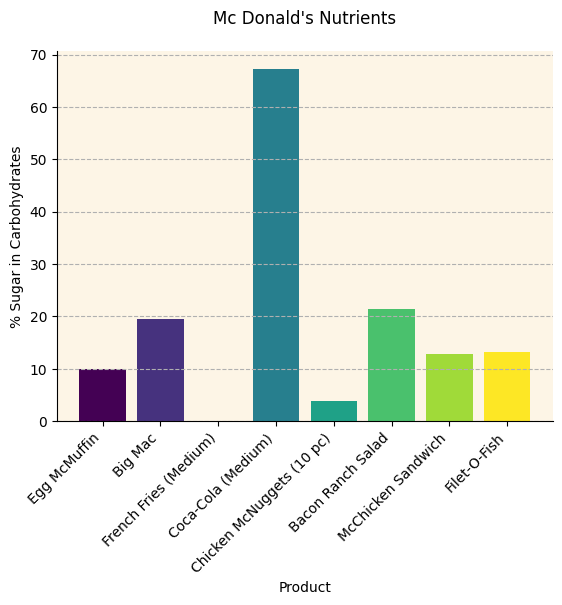

In [9]:
fig, ax = plt.subplots()

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(df["Item"])))

ax.bar(df["Item"], df["% Sugar in Carbohydrates"], color=colors)
ax.set_xticks(df["Item"])
ax.set_xticklabels(df["Item"], rotation=45, ha="right")
ax.set_title("Mc Donald's Nutrients", pad=20)
ax.grid(axis="y", linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel("% Sugar in Carbohydrates")
ax.set_xlabel("Product")
ax.set_facecolor("#FDF5E6")

plt.show()

In [43]:
"""
Create a new column called Health Score that rates each item on a scale of 1 to 100 
based on the following formula:

Health Score = (Protein (g) * 4 - Total Fat (g) * 2 - Sugars (g) * 1)
After calculating the health scores, identify the item with the highest health score. Display its name, category, 
and health score.
"""

df["Health Score"] = (df["Protein (g)"] * 4) - (df["Total Fat (g)"] * 2) - (df["Sugars (g)"] * 1)
number_one = df.nlargest(1, "Health Score")[["Item", "Category", "Health Score"]].reset_index(drop=True)

number_one

,Item,Category,Health Score
0,Bacon Ranch Salad,Salads,85


In [53]:
healtiest_item = number_one.loc[0, "Item"]
healtiest_category = number_one.loc[0, "Category"]
healtiest_score = number_one.loc[0, "Health Score"]

print(f"{healtiest_item} in the {healtiest_category} category is the Mc.Donald's healtiest choice with a health score of {healtiest_score} points.")

Bacon Ranch Salad in the Salads category is the Mc.Donald's healtiest choice with a health score of 85 points.


In [88]:
from itertools import combinations

combinations_list = list(combinations(df.index, 2))

results = []

for snack1, snack2 in combinations_list:
    total_protein = df.loc[snack1, "Protein (g)"] + df.loc[snack2, "Protein (g)"]
    total_calories = df.loc[snack1, "Calories"] + df.loc[snack2, "Calories"]

    if total_calories < 600:
        results.append({
            "Item 1": df.loc[snack1, "Item"],
            "Item 2": df.loc[snack2, "Item"],
            "Total Protein (g)": total_protein,
            "Total Calories": total_calories
        })

results_df = pd.DataFrame(results)

top_combinations = results_df.sort_values(by="Total Protein (g)", ascending=False).head(3)
top_combinations

,Item 1,Item 2,Total Protein (g),Total Calories
2,Coca-Cola (Medium),Bacon Ranch Salad,29,530
0,Egg McMuffin,Coca-Cola (Medium),17,510
3,Coca-Cola (Medium),Filet-O-Fish,14,590


In [112]:
"""
You are tasked with finding the combination of two menu items that minimizes 
the total sodium content while keeping the combined calories between 400 and 700. For each valid combination, 
calculate:

The total sodium content.
The combined calorie count.
The names of the two items.
Display the combination with the lowest sodium content and provide its details.
"""

from itertools import combinations

combinations_list = list(combinations(df.index, 2))

results = []

for snack1, snack2 in combinations_list:
    total_sodium = df.loc[snack1, "Sodium (mg)"] + df.loc[snack2, "Sodium (mg)"]
    total_calories = df.loc[snack1, "Calories"] + df.loc[snack2, "Calories"]

    if total_calories > 400 and total_calories < 700:
        results.append({
            "Item 1": df.loc[snack1, "Item"],
            "Item 2": df.loc[snack2, "Item"],
            "Sodium (mg)": total_sodium, 
            "Calories": total_calories
        })

results_df = pd.DataFrame(results)

#top_combinations = df.loc[(results_df["Calories"] < 700) & (results_df["Calories"] > 400)]
top_combinations = results_df.sort_values(by="Sodium (mg)", ascending=True).head(3)
top_combinations

,Item 1,Item 2,Sodium (mg),Calories
4,French Fries (Medium),Coca-Cola (Medium),305,588
9,Coca-Cola (Medium),Filet-O-Fish,595,590
8,Coca-Cola (Medium),McChicken Sandwich,685,610


In [121]:
"""
You are tasked with finding the combination of two menu items that provides the 
most balanced ratio of protein to total calories. For each combination:

Calculate the combined protein and calorie count.
Compute the Protein-to-Calorie Ratio as:
Protein-to-Calorie Ratio
=
Total Protein (g)
Total Calories
Protein-to-Calorie Ratio= 
Total Calories
Total Protein (g)
​	
 
Identify the top 3 combinations with the highest Protein-to-Calorie Ratios.
"""

from itertools import combinations

combinations_list = list(combinations(df.index, 2))

results = []

for snack1, snack2 in combinations_list:
    total_protein = df.loc[snack1, "Protein (g)"] + df.loc[snack2, "Protein (g)"]
    total_calories = df.loc[snack1, "Calories"] + df.loc[snack2, "Calories"]
    protein_calorie_ratio = round(total_protein / total_calories, 3)

    results.append({
        "Item 1": df.loc[snack1, "Item"],
        "Item 2": df.loc[snack2, "Item"],
        "Protein (g)": total_protein,
        "Calories": total_calories,
        "Protein/Calories Ratio" : protein_calorie_ratio
    })

results_df = pd.DataFrame(results)

top_combinations = results_df.sort_values(by="Protein/Calories Ratio", ascending=False).head(3)
top_combinations   

,Item 1,Item 2,Protein (g),Calories,Protein/Calories Ratio
4,Egg McMuffin,Bacon Ranch Salad,46,620,0.074
22,Chicken McNuggets (10 pc),Bacon Ranch Salad,53,760,0.070
26,Bacon Ranch Salad,Filet-O-Fish,43,700,0.061
